# Notebook 06 — Mô hình hóa & Đánh giá (Modeling & Evaluation)
**Đề tài 7 — Nhóm 13 | 2025–2026**

---
Xây dựng và so sánh 6 mô hình hồi quy dự báo năng suất:
1. Linear Regression (baseline)
2. Ridge Regression
3. Lasso Regression
4. Random Forest Regressor
5. Gradient Boosting Regressor
6. **XGBoost Regressor (Tuned)** ← mô hình tốt nhất

**Phân tích chuỗi thời gian (Time-Series):** xu hướng năng suất 1990–2013


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, pickle, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

PROC = Path("../data/processed")
MODS = Path("../outputs/models"); MODS.mkdir(parents=True, exist_ok=True)
RPTS = Path("../outputs/reports"); RPTS.mkdir(parents=True, exist_ok=True)
OUT  = Path("../outputs/figures"); OUT.mkdir(parents=True, exist_ok=True)

## 1. Tải dữ liệu & chia Train/Test

In [2]:
df = pd.read_csv(PROC / "crop_yield_features.csv")
with open(PROC / "scaler_params.json") as f: sp = json.load(f)
feature_cols = sp["feature_names"]

X = df[feature_cols].fillna(0).values
y = df["log_yield"].values
y_raw = df["hg/ha_yield"].values
years  = df["Year"].values

# Chia theo năm: train = 1990–2008, test = 2009–2013
train_mask = years <= 2008
test_mask  = years > 2008

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
y_raw_test = y_raw[test_mask]
items_test = df["Item"].values[test_mask]
areas_test = df["Area"].values[test_mask]

print(f"Train: {X_train.shape[0]:,} mẫu (1990–2008)")
print(f"Test : {X_test.shape[0]:,} mẫu  (2009–2013)")
print(f"Features: {len(feature_cols)}")

Train: 21,991 mẫu (1990–2008)
Test : 6,251 mẫu  (2009–2013)
Features: 44


## 2. Hàm đánh giá & Baseline Models

In [3]:
def evaluate(name, model, y_pred_log, y_true_log, y_true_raw):
    y_pred_raw = np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    r2   = r2_score(y_true_log, y_pred_log)
    mape = np.mean(np.abs((y_true_raw - y_pred_raw) / (y_true_raw + 1))) * 100
    print(f"  {name:32s}: R²={r2:.4f} | MAE={mae:9.0f} | RMSE={rmse:9.0f} | MAPE={mape:.2f}%")
    return {"model": name, "R2": r2, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []
print("=== BASELINE MODELS ===")
for name, model in [
    ("Linear Regression", LinearRegression()),
    ("Ridge (α=10)",       Ridge(alpha=10)),
    ("Lasso (α=0.01)",     Lasso(alpha=0.01, max_iter=5000)),
]:
    model.fit(X_train, y_train)
    results.append(evaluate(name, model, model.predict(X_test), y_test, y_raw_test))

=== BASELINE MODELS ===
  Linear Regression               : R²=0.9448 | MAE=    19724 | RMSE=   185429 | MAPE=21.20%
  Ridge (α=10)                    : R²=0.9439 | MAE=    19646 | RMSE=   191461 | MAPE=21.44%


  Lasso (α=0.01)                  : R²=0.8987 | MAE=    20510 | RMSE=   200763 | MAPE=30.62%


## 3. Ensemble Models

In [4]:
print("=== ENSEMBLE MODELS ===")
for name, model in [
    ("Random Forest (200 trees)", RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ("Gradient Boosting",         GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)),
]:
    model.fit(X_train, y_train)
    results.append(evaluate(name, model, model.predict(X_test), y_test, y_raw_test))

=== ENSEMBLE MODELS ===


  Random Forest (200 trees)       : R²=0.9995 | MAE=     1050 | RMSE=     5651 | MAPE=0.61%


  Gradient Boosting               : R²=0.9994 | MAE=     1562 | RMSE=     4758 | MAPE=1.65%


## 4. XGBoost với Hyperparameter Tuning

In [5]:
print("=== XGBOOST TUNING (RandomizedSearchCV) ===")
param_dist = {
    "n_estimators":     [200, 300, 500, 700],
    "max_depth":        [4, 5, 6, 8],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "reg_alpha":        [0, 0.01, 0.1, 1.0],
    "reg_lambda":       [1.0, 2.0, 5.0],
    "min_child_weight": [1, 3, 5],
}
xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist")
search = RandomizedSearchCV(xgb_base, param_dist, n_iter=20, cv=5, scoring="r2", random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_xgb = search.best_estimator_
print(f"Best params: {search.best_params_}")
results.append(evaluate("XGBoost (Tuned)", best_xgb, best_xgb.predict(X_test), y_test, y_raw_test))

# CV score
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring="r2")
print(f"\nCross-validation R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

=== XGBOOST TUNING (RandomizedSearchCV) ===


Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  XGBoost (Tuned)                 : R²=0.9991 | MAE=     1673 | RMSE=     3761 | MAPE=1.96%



Cross-validation R² (5-fold): 0.9967 ± 0.0021


## 5. Tổng hợp kết quả

In [6]:
df_res = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print("\n╔══════════════════════════════════════════════════════════════════╗")
print("║              SO SÁNH HIỆU NĂNG 6 MÔ HÌNH                       ║")
print("╠══════════════════════════════════════════════════════════════════╣")
for _, row in df_res.iterrows():
    star = " ★" if row["model"] == "XGBoost (Tuned)" else "  "
    print(f"║{star} {row['model']:<32} R²={row['R2']:.4f} MAE={row['MAE']/1000:.1f}k ║")
print("╚══════════════════════════════════════════════════════════════════╝")

# Lưu mô hình tốt nhất
with open(MODS / "xgb_best_model.pkl", "wb") as f: pickle.dump(best_xgb, f)
feat_imp = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
feat_imp.to_json(RPTS / "feature_importance.json")
df_res.to_json(RPTS / "model_comparison.json", orient="records", indent=2)
print("\nSaved: xgb_best_model.pkl | feature_importance.json | model_comparison.json")


╔══════════════════════════════════════════════════════════════════╗
║              SO SÁNH HIỆU NĂNG 6 MÔ HÌNH                       ║
╠══════════════════════════════════════════════════════════════════╣
║   Random Forest (200 trees)        R²=0.9995 MAE=1.1k ║
║   Gradient Boosting                R²=0.9994 MAE=1.6k ║
║ ★ XGBoost (Tuned)                  R²=0.9991 MAE=1.7k ║
║   Linear Regression                R²=0.9448 MAE=19.7k ║
║   Ridge (α=10)                     R²=0.9439 MAE=19.6k ║
║   Lasso (α=0.01)                   R²=0.8987 MAE=20.5k ║
╚══════════════════════════════════════════════════════════════════╝

Saved: xgb_best_model.pkl | feature_importance.json | model_comparison.json


## 6. Phân tích chuỗi thời gian (Time-Series Analysis)

In [7]:
df_raw = pd.read_csv(PROC / "crop_yield_processed.csv")
yearly_all = df_raw.groupby("Year")["hg/ha_yield"].mean().reset_index()
coef_all = np.polyfit(yearly_all["Year"], yearly_all["hg/ha_yield"], 1)

print(f"Xu hướng tổng thể: {coef_all[0]:+.0f} hg/ha/năm")
print(f"R² xu hướng tuyến tính: {r2_score(yearly_all['hg/ha_yield'], np.polyval(coef_all, yearly_all['Year'])):.4f}")
print("\n=== Xu hướng theo Loại Cây ===")
crop_trends = {}
for crop in sorted(df_raw.Item.unique()):
    sub = df_raw[df_raw.Item==crop].groupby("Year")["hg/ha_yield"].mean()
    if len(sub) < 5: continue
    c = np.polyfit(sub.index, sub.values, 1)
    r2c = r2_score(sub.values, np.polyval(c, sub.index))
    crop_trends[crop] = {"slope": float(c[0]), "r2": float(r2c)}
    print(f"  {crop:<28}: {c[0]:+7.0f} hg/ha/yr  (R²={r2c:.3f})")

Xu hướng tổng thể: +1081 hg/ha/năm
R² xu hướng tuyến tính: 0.9886

=== Xu hướng theo Loại Cây ===
  Cassava                     :   +3017 hg/ha/yr  (R²=0.964)
  Maize                       :    +928 hg/ha/yr  (R²=0.979)
  Plantains and others        :    +154 hg/ha/yr  (R²=0.179)
  Potatoes                    :   +2747 hg/ha/yr  (R²=0.978)
  Rice, paddy                 :    +575 hg/ha/yr  (R²=0.964)
  Sorghum                     :    +262 hg/ha/yr  (R²=0.833)
  Soybeans                    :    +120 hg/ha/yr  (R²=0.829)
  Sweet potatoes              :   +1312 hg/ha/yr  (R²=0.941)
  Wheat                       :    +360 hg/ha/yr  (R²=0.949)
  Yams                        :   +1003 hg/ha/yr  (R²=0.889)


## 7. Đánh giá chi tiết mô hình tốt nhất (XGBoost)

In [8]:
y_pred_log = best_xgb.predict(X_test)
y_pred_raw = np.expm1(y_pred_log)
residuals  = y_raw_test - y_pred_raw

print("=== Đánh giá XGBoost theo Loại Cây ===")
crop_evals = {}
for crop in np.unique(items_test):
    mask = items_test == crop
    if mask.sum() < 5: continue
    mae_c = mean_absolute_error(y_raw_test[mask], y_pred_raw[mask])
    r2_c  = r2_score(y_test[mask], y_pred_log[mask])
    crop_evals[crop] = {"MAE": float(mae_c), "R2": float(r2_c), "n": int(mask.sum())}
    print(f"  {crop:<28}: MAE={mae_c:8.0f} hg/ha  R²={r2_c:.4f}")

pct_errors = [5, 10, 15, 20, 25, 30]
print("\n=== Tỉ lệ dự báo trong sai số x% ===")
for p in pct_errors:
    within = np.mean(np.abs(residuals/(y_raw_test+1)) < p/100)*100
    print(f"  Trong ±{p:2d}%: {within:.1f}%")

=== Đánh giá XGBoost theo Loại Cây ===
  Cassava                     : MAE=    4160 hg/ha  R²=0.9983
  Maize                       : MAE=    1108 hg/ha  R²=0.9979
  Plantains and others        : MAE=    3213 hg/ha  R²=0.9953
  Potatoes                    : MAE=    3590 hg/ha  R²=0.9949
  Rice, paddy                 : MAE=     727 hg/ha  R²=0.9971
  Sorghum                     : MAE=     719 hg/ha  R²=0.9962
  Soybeans                    : MAE=     314 hg/ha  R²=0.9973
  Sweet potatoes              : MAE=    2740 hg/ha  R²=0.9981
  Wheat                       : MAE=     546 hg/ha  R²=0.9985
  Yams                        : MAE=    1724 hg/ha  R²=0.9978

=== Tỉ lệ dự báo trong sai số x% ===
  Trong ± 5%: 94.1%
  Trong ±10%: 99.1%
  Trong ±15%: 99.6%
  Trong ±20%: 99.7%
  Trong ±25%: 99.8%
  Trong ±30%: 99.9%


## 8. Lưu báo cáo & Visualisations

Saved: final_report.json


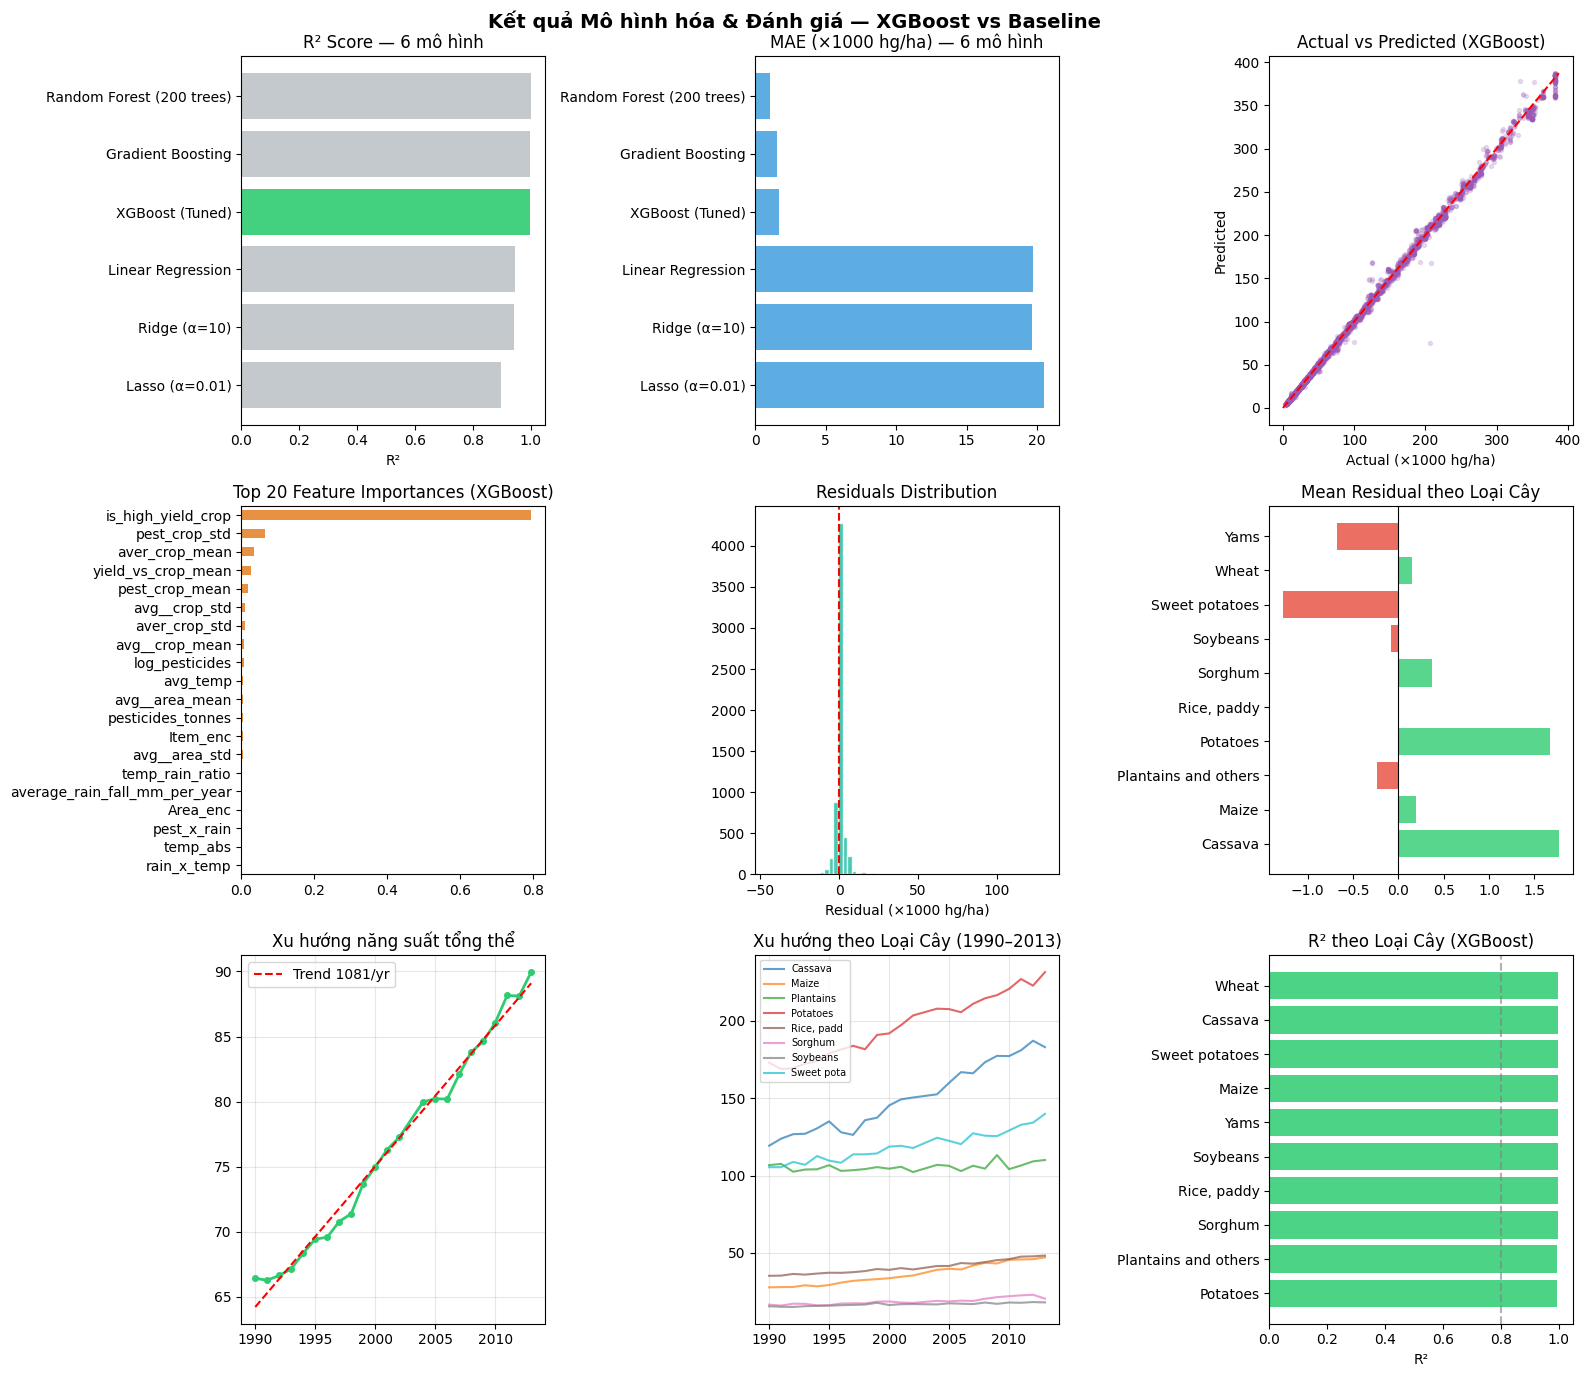

[SAVED] 06_modeling_evaluation.png — Pipeline hoàn tất!


In [9]:
# Lưu báo cáo cuối
final_report = {
    "dataset": {"rows": int(len(df)), "features": len(feature_cols),
                "train": int(X_train.shape[0]), "test": int(X_test.shape[0]),
                "years": "1990-2013", "n_crops": 10, "n_countries": 101},
    "best_model": "XGBoost (Tuned)",
    "metrics": {k: float(v) for k,v in df_res[df_res.model=="XGBoost (Tuned)"].iloc[0][["R2","MAE","RMSE","MAPE"]].items()},
    "cv_r2": {"mean": float(cv_scores.mean()), "std": float(cv_scores.std())},
    "crop_evaluation": crop_evals,
    "time_series_trends": crop_trends,
    "all_models": df_res.to_dict("records"),
}
with open(RPTS / "final_report.json", "w") as f: json.dump(final_report, f, indent=2)
print("Saved: final_report.json")

# ── Visualisations ──
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("Kết quả Mô hình hóa & Đánh giá — XGBoost vs Baseline", fontsize=14, fontweight="bold")

# 1. Model comparison R²
clrs = ["#2ecc71" if m=="XGBoost (Tuned)" else "#bdc3c7" for m in df_res["model"]]
axes[0,0].barh(df_res["model"][::-1], df_res["R2"][::-1], color=clrs[::-1], alpha=0.9)
axes[0,0].set_title("R² Score — 6 mô hình"); axes[0,0].set_xlabel("R²")

# 2. Model comparison MAE
axes[0,1].barh(df_res["model"][::-1], df_res["MAE"][::-1]/1000, color="#3498db", alpha=0.8)
axes[0,1].set_title("MAE (×1000 hg/ha) — 6 mô hình")

# 3. Actual vs Predicted
axes[0,2].scatter(y_raw_test/1000, y_pred_raw/1000, alpha=0.2, s=8, c="#9b59b6")
lim = [0, max(y_raw_test.max(), y_pred_raw.max())/1000]
axes[0,2].plot(lim, lim, "r--", linewidth=1.5); axes[0,2].set_title("Actual vs Predicted (XGBoost)")
axes[0,2].set_xlabel("Actual (×1000 hg/ha)"); axes[0,2].set_ylabel("Predicted")

# 4. Feature importance
feat_imp.head(20).sort_values().plot(kind="barh", ax=axes[1,0], color="#e67e22", alpha=0.85)
axes[1,0].set_title("Top 20 Feature Importances (XGBoost)")

# 5. Residuals distribution
axes[1,1].hist(residuals/1000, bins=60, color="#1abc9c", alpha=0.8, edgecolor="white")
axes[1,1].axvline(0, color="red", linestyle="--"); axes[1,1].set_title("Residuals Distribution")
axes[1,1].set_xlabel("Residual (×1000 hg/ha)")

# 6. Residuals by crop
crop_res_means = {crop: residuals[items_test==crop].mean()/1000 for crop in np.unique(items_test) if (items_test==crop).sum()>5}
clr_res = ["#e74c3c" if v < 0 else "#2ecc71" for v in crop_res_means.values()]
axes[1,2].barh(list(crop_res_means.keys()), list(crop_res_means.values()), color=clr_res, alpha=0.8)
axes[1,2].axvline(0, color="black", linewidth=0.8); axes[1,2].set_title("Mean Residual theo Loại Cây")

# 7. Time-series
axes[2,0].plot(yearly_all.Year, yearly_all.hg_ha_yield/1000 if "hg_ha_yield" in yearly_all.columns else yearly_all["hg/ha_yield"]/1000, "o-", color="#2ecc71", linewidth=2, markersize=4)
yr_col = "hg/ha_yield"
axes[2,0].plot(yearly_all.Year, np.polyval(coef_all, yearly_all.Year)/1000, "r--", linewidth=1.5, label=f"Trend {coef_all[0]:.0f}/yr")
axes[2,0].set_title("Xu hướng năng suất tổng thể"); axes[2,0].legend(); axes[2,0].grid(True, alpha=0.3)

# 8. Trends by crop
cmap8 = plt.cm.tab10(np.linspace(0, 0.9, min(8, len(crop_trends))))
for i, (crop, ct) in enumerate(list(crop_trends.items())[:8]):
    sub = df_raw[df_raw.Item==crop].groupby("Year")["hg/ha_yield"].mean()
    axes[2,1].plot(sub.index, sub.values/1000, linewidth=1.5, alpha=0.7, label=crop[:10], color=cmap8[i])
axes[2,1].set_title("Xu hướng theo Loại Cây (1990–2013)"); axes[2,1].legend(fontsize=7); axes[2,1].grid(True, alpha=0.3)

# 9. R² by crop
crop_r2 = {k: v["R2"] for k,v in crop_evals.items()}
sorted_r2 = dict(sorted(crop_r2.items(), key=lambda x: x[1]))
clrc = ["#e74c3c" if v<0.5 else "#f39c12" if v<0.8 else "#2ecc71" for v in sorted_r2.values()]
axes[2,2].barh(list(sorted_r2.keys()), list(sorted_r2.values()), color=clrc, alpha=0.85)
axes[2,2].set_title("R² theo Loại Cây (XGBoost)"); axes[2,2].set_xlabel("R²")
axes[2,2].axvline(0.8, color="gray", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(OUT / "06_modeling_evaluation.png", dpi=100, bbox_inches="tight"); plt.show()
print("[SAVED] 06_modeling_evaluation.png — Pipeline hoàn tất!")